# **Model Comparison**

Final comparison of all trained models against the Logistic Regression baseline.
No training is performed here — all results are loaded from saved artifacts.

Models evaluated:
- Logistic Regression (Baseline)
- Random Forest (Default)
- Random Forest (Tuned)
- XGBoost (Default)
- XGBoost (Tuned)

#### Library imports

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay
import category_encoders as ce

In [2]:
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

In [3]:
from utils import load_results # type: ignore

### **1. Metrics Comparison**

In [4]:
results = load_results()
results

,model,timestamp,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1,roc_auc,confusion_matrix
0,Logistic Regression (Baseline),2026-05-27 20:30,0.716,0.7871,0.7174,0.7506,0.6302,0.7128,0.6690,0.7098,0.7177,0.7925,"[[17583, 6926], [4757, 11805]]"
1,XGBoost (Baseline),2026-05-28 01:12,0.725,0.7884,0.7362,0.7614,0.6444,0.7075,0.6745,0.7180,0.7264,0.8025,"[[18044, 6465], [4844, 11718]]"
2,XGBoost (Tuned),2026-05-28 01:15,0.724,0.7896,0.7329,0.7602,0.6427,0.7110,0.6751,0.7176,0.7259,0.8031,"[[17962, 6547], [4787, 11775]]"
3,Random Forest (Baseline),2026-05-28 01:46,0.714,0.7333,0.8174,0.7731,0.6745,0.5600,0.6120,0.6925,0.7081,0.7798,"[[20034, 4475], [7287, 9275]]"
4,Random Forest (Tuned),2026-05-28 02:11,0.724,0.7878,0.7357,0.7609,0.6438,0.7068,0.6738,0.7173,0.7258,0.8027,"[[18031, 6478], [4856, 11706]]"


### **2. Metrics Bar Chart**

In [5]:
metrics = ['f1_0', 'f1_1', 'macro_f1', 'roc_auc']
labels  = ['F1 (Material)', 'F1 (Injured/Dead)', 'F1 (Macro)', 'AUC-ROC']

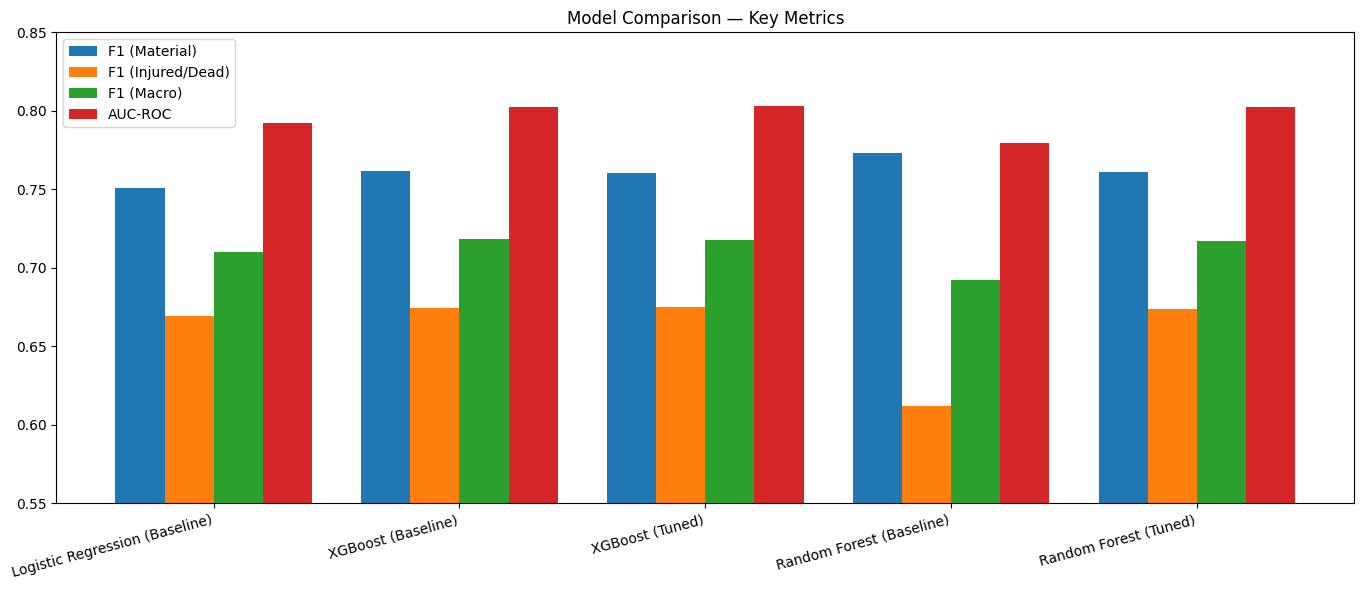

In [6]:
x = np.arange(len(results['model']))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, label) in enumerate(zip(metrics, labels)):
    ax.bar(x + i * width, results[metric], width, label=label)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['model'], rotation=15, ha='right')
ax.set_ylim(0.55, 0.85)
ax.set_title("Model Comparison — Key Metrics")
ax.legend()
plt.tight_layout()
plt.show()

### **3. ROC Curves — All Models**

Load data and encoders to reconstruct test sets per model.

In [7]:
data = pd.read_excel('../data/processed/accident_processed_srb.xlsx')

In [8]:
y = data['accident_type']
X = data.drop(columns=['accident_type'])

In [9]:
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
models = {
    'LR (Baseline)':   {
        'model': joblib.load('../models/logistic_regression_baseline.pkl'),
        'encoder': joblib.load('../models/encoders/lr_mun_target_encoder.pkl'),
        'scaler': joblib.load('../models/scalers/lr_standard_scaler.pkl'),
    },
    'RF (Baseline)':    {
        'model': joblib.load('../models/random_forest_baseline.pkl'),
        'encoder': joblib.load('../models/encoders/rf_mun_target_encoder.pkl'),
        'scaler': None,
    },
    'RF (Tuned)':      {
        'model': joblib.load('../models/random_forest_tuned.pkl'),
        'encoder': joblib.load('../models/encoders/rf_mun_target_encoder.pkl'),
        'scaler': None,
    },
    'XGB (Baseline)':   {
        'model': joblib.load('../models/xgboost_baseline.pkl'),
        'encoder': joblib.load('../models/encoders/xgb_mun_target_encoder.pkl'),
        'scaler': None,
    },
    'XGB (Tuned)':     {
        'model': joblib.load('../models/xgboost_tuned.pkl'),
        'encoder': joblib.load('../models/encoders/xgb_mun_target_encoder.pkl'),
        'scaler': None,
    },
}

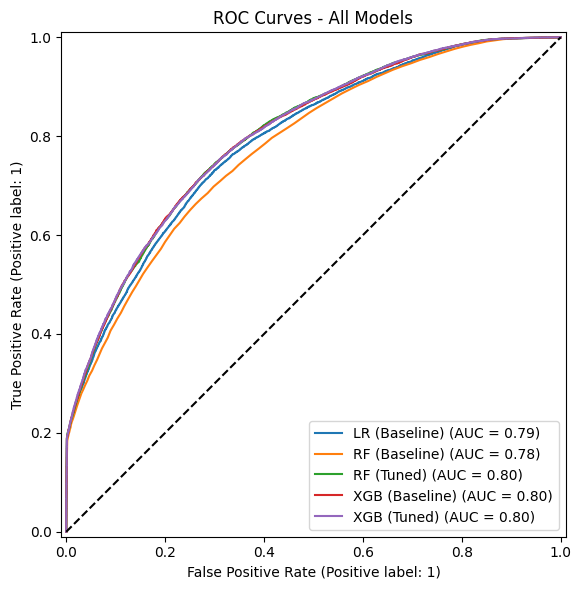

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, artifacts in models.items():
    X_test_copy = X_test.copy()

    encoder = artifacts['encoder']
    X_test_copy['municipality'] = encoder.transform(X_test_copy['municipality'])

    scaler = artifacts['scaler']
    if scaler is not None:
        X_test_copy = scaler.transform(X_test_copy)

    RocCurveDisplay.from_estimator(
        artifacts['model'],
        X_test_copy,
        y_test,
        name=name,
        ax=ax
    )

ax.set_title("ROC Curves - All Models")
ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.tight_layout()
plt.show()

### **4. Summary Table**

In [12]:
baseline_auc = results.loc[results['model'] == 'Logistic Regression (Baseline)', 'roc_auc'].values[0]

summary = results[['model', 'accuracy', 'f1_0', 'f1_1', 'macro_f1', 'roc_auc']].copy()
summary = summary.rename(columns={
    'model':     'Model',
    'accuracy':  'Accuracy',
    'f1_0':      'F1 (Material)',
    'f1_1':      'F1 (Injured/Dead)',
    'macro_f1':  'F1 (Macro)',
    'roc_auc':   'AUC-ROC'
})
summary['vs Baseline (AUC)'] = (summary['AUC-ROC'] - baseline_auc).round(4)
summary = summary.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

summary

,Model,Accuracy,F1 (Material),F1 (Injured/Dead),F1 (Macro),AUC-ROC,vs Baseline (AUC)
0,XGBoost (Tuned),0.724,0.7602,0.6751,0.7176,0.8031,0.0106
1,Random Forest (Tuned),0.724,0.7609,0.6738,0.7173,0.8027,0.0102
2,XGBoost (Baseline),0.725,0.7614,0.6745,0.7180,0.8025,0.0100
3,Logistic Regression (Baseline),0.716,0.7506,0.6690,0.7098,0.7925,0.0000
4,Random Forest (Baseline),0.714,0.7731,0.6120,0.6925,0.7798,-0.0127


### **Conclusion:**

**XGBoost (Tuned)** achieves the best overall performance (AUC = 0.8031), 
followed closely by Random Forest (Tuned) (AUC = 0.8027).

Key findings:
- Default Random Forest is the only model that underperforms the LR baseline, 
  confirming that tree-based models without tuning are not automatically superior.
- All tuned models consistently outperform the baseline by ~+0.01 AUC.
- Convergence of all tuned models toward AUC ~0.80 suggests the current feature 
  set has reached its informational ceiling.
- Further improvement would likely require additional data not present in 
  administrative records (vehicle speed, road conditions, driver state).